# 04 - Advanced EDA

Deeper relationships that may help model performance: toss winner vs match winner, venue/home advantage, head-to-head records, season-wise team performance, and correlations between numerical features.

Charts are saved to `../images/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
IMAGES_DIR = '../images'
os.makedirs(IMAGES_DIR, exist_ok=True)

matches = pd.read_csv('../data/processed/matches_cleaned.csv', parse_dates=['date'])
matches.shape

(1212, 11)

## Toss winner vs match winner

Does winning the toss actually help win the match?

toss_win_match_win
True     50.577558
False    49.422442
Name: proportion, dtype: float64


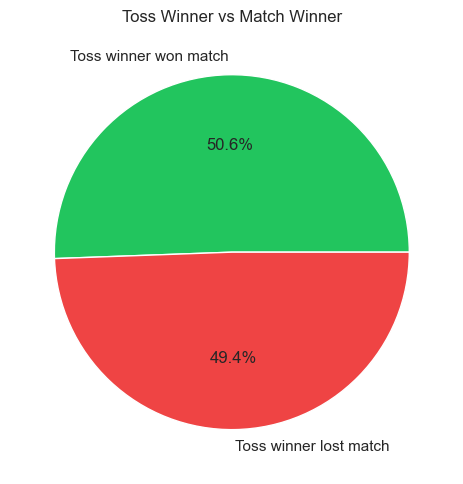

In [2]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_win_match_win'].value_counts(normalize=True) * 100
print(toss_impact)

fig, ax = plt.subplots(figsize=(5, 5))
toss_impact.rename({True: 'Toss winner won match', False: 'Toss winner lost match'}).plot(
    kind='pie', ax=ax, autopct='%1.1f%%', colors=['#22c55e', '#ef4444'], ylabel=''
)
ax.set_title('Toss Winner vs Match Winner')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/toss_winner_vs_match_winner.png', dpi=150)
plt.show()

## Venue advantage

Win percentage by venue (venues with at least 10 matches).

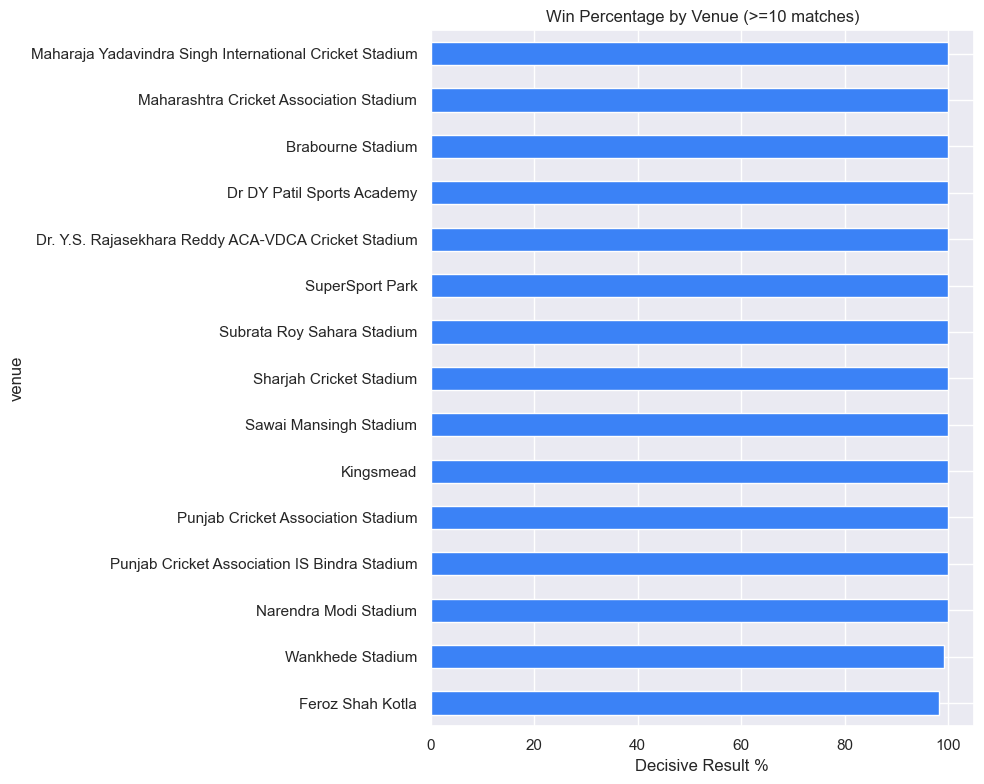

In [3]:
venue_matches = matches['venue'].value_counts()
venue_wins = matches.groupby('venue')['winner'].count()

# win % here = share of the venue's matches that produced a decisive result (not a tie/no-result)
decisive = matches[matches['winner'].notna()]
venue_decisive_pct = (decisive.groupby('venue').size() / venue_matches * 100).dropna()
venue_decisive_pct = venue_decisive_pct[venue_matches >= 10].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
venue_decisive_pct.head(15).plot(kind='barh', ax=ax, color='#3b82f6')
ax.invert_yaxis()
ax.set_title('Win Percentage by Venue (>=10 matches)')
ax.set_xlabel('Decisive Result %')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/win_percentage_by_venue.png', dpi=150)
plt.show()

## Home advantage

Approximate "home" as a team playing in its most frequent city. Compare win rate at home vs away.

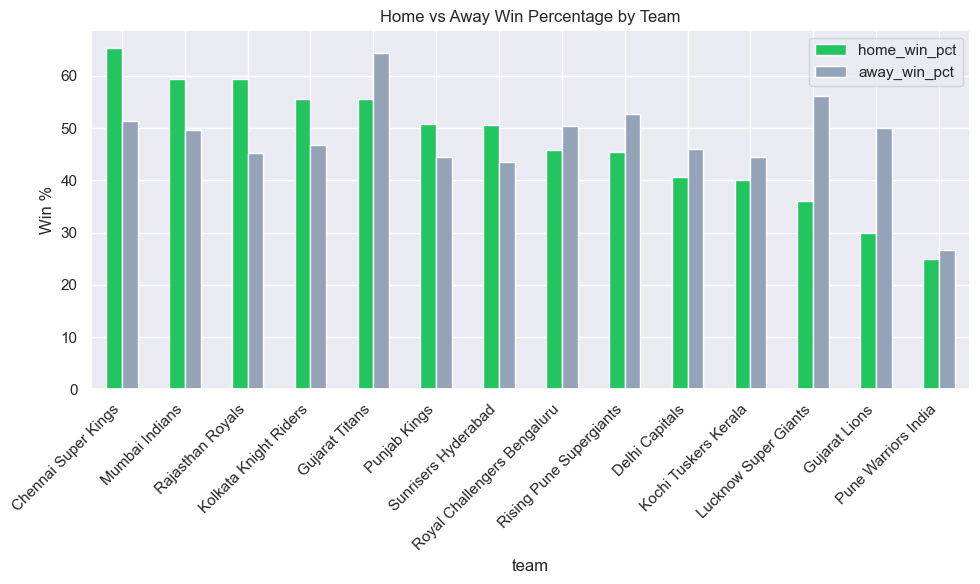

In [4]:
team_home_city = {}
for team in pd.concat([matches['team1'], matches['team2']]).unique():
    team_matches = matches[(matches['team1'] == team) | (matches['team2'] == team)]
    if not team_matches.empty:
        team_home_city[team] = team_matches['city'].value_counts().idxmax()

rows = []
for team, home_city in team_home_city.items():
    team_matches = matches[(matches['team1'] == team) | (matches['team2'] == team)]
    home = team_matches[team_matches['city'] == home_city]
    away = team_matches[team_matches['city'] != home_city]
    home_win_pct = (home['winner'] == team).mean() * 100 if len(home) else np.nan
    away_win_pct = (away['winner'] == team).mean() * 100 if len(away) else np.nan
    rows.append({'team': team, 'home_win_pct': home_win_pct, 'away_win_pct': away_win_pct})

home_advantage = pd.DataFrame(rows).dropna().sort_values('home_win_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
home_advantage.set_index('team')[['home_win_pct', 'away_win_pct']].plot(kind='bar', ax=ax, color=['#22c55e', '#94a3b8'])
ax.set_title('Home vs Away Win Percentage by Team')
ax.set_ylabel('Win %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/home_advantage.png', dpi=150)
plt.show()

## Head-to-head team records

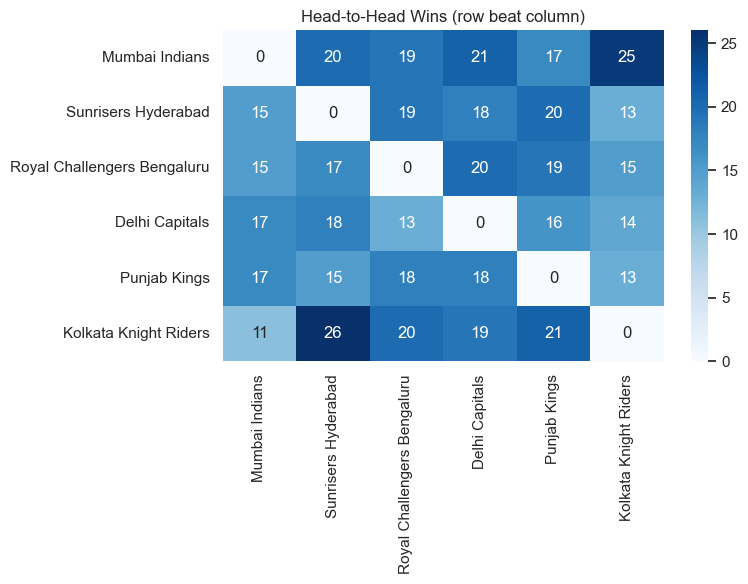

In [5]:
def head_to_head(team_a, team_b, df):
    pairs = df[
        ((df['team1'] == team_a) & (df['team2'] == team_b))
        | ((df['team1'] == team_b) & (df['team2'] == team_a))
    ]
    return pairs['winner'].value_counts()

top_teams = pd.concat([matches['team1'], matches['team2']]).value_counts().head(6).index.tolist()
h2h_matrix = pd.DataFrame(index=top_teams, columns=top_teams, dtype=float)

for a in top_teams:
    for b in top_teams:
        if a == b:
            continue
        record = head_to_head(a, b, matches)
        h2h_matrix.loc[a, b] = record.get(a, 0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(h2h_matrix.fillna(0), annot=True, fmt='.0f', cmap='Blues', ax=ax)
ax.set_title('Head-to-Head Wins (row beat column)')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/head_to_head_heatmap.png', dpi=150)
plt.show()

## Season-wise team performance

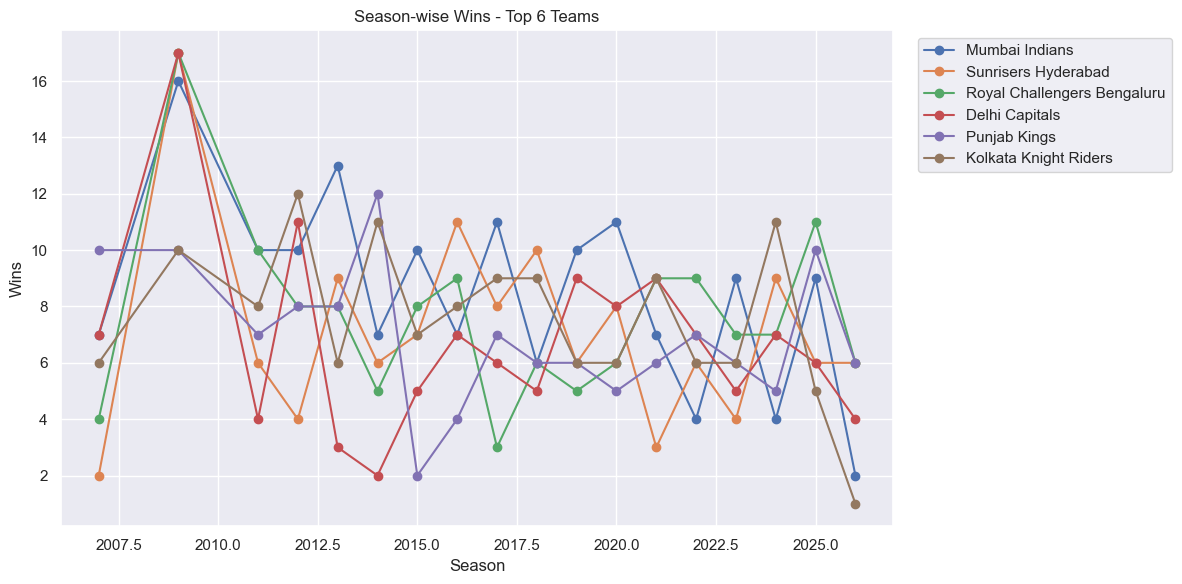

In [6]:
season_wins = matches.groupby(['season', 'winner']).size().unstack(fill_value=0)
top6_season_wins = season_wins[top_teams]

fig, ax = plt.subplots(figsize=(12, 6))
top6_season_wins.plot(ax=ax, marker='o')
ax.set_title('Season-wise Wins - Top 6 Teams')
ax.set_xlabel('Season')
ax.set_ylabel('Wins')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/season_wise_team_performance.png', dpi=150)
plt.show()

## Team performance consistency (box plot)

Spread of each top-6 team's per-season win count — a tight box means consistent performance across years, a wide one means boom-or-bust seasons.

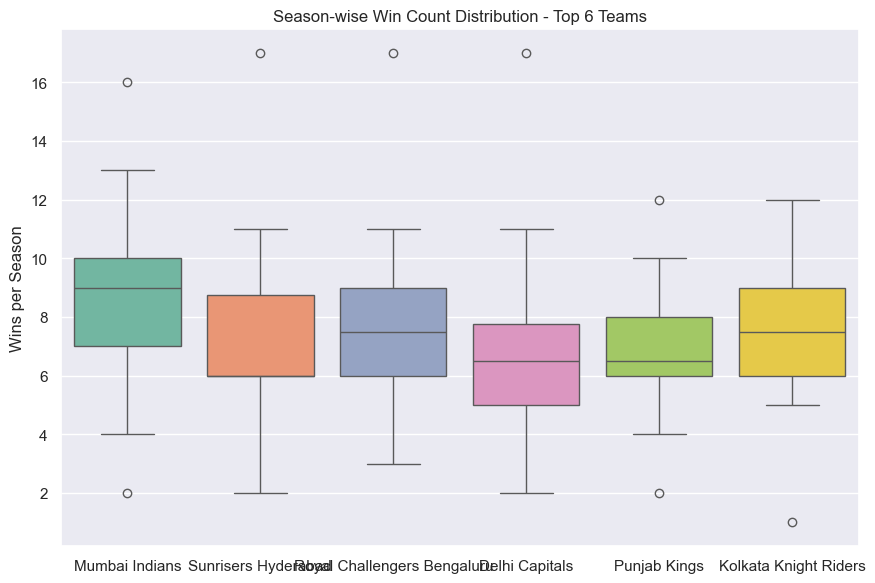

In [7]:
season_wins_long = top6_season_wins.reset_index().melt(id_vars='season', var_name='team', value_name='wins')

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=season_wins_long, x='team', y='wins', ax=ax, hue='team', palette='Set2', legend=False)
ax.set_title('Season-wise Win Count Distribution - Top 6 Teams')
ax.set_xlabel('')
ax.set_ylabel('Wins per Season')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/team_performance_boxplot.png', dpi=150)
plt.show()

## Correlation between numerical features

Build a small numeric feature set (season, toss-match-win flag, batting-first flag, home-match flag) to check correlations.

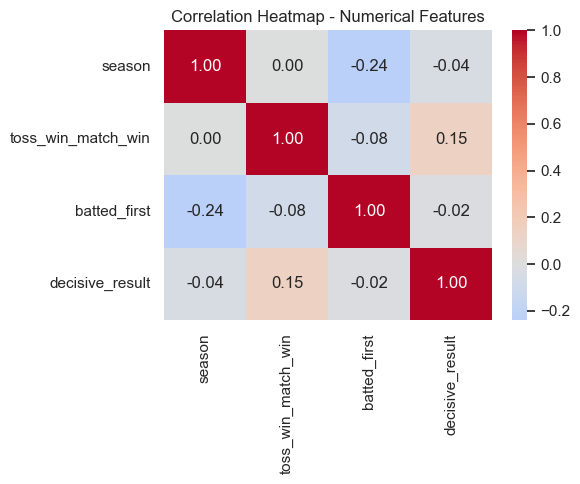

In [8]:
numeric_features = pd.DataFrame({
    'season': matches['season'],
    'toss_win_match_win': matches['toss_win_match_win'].astype(int),
    'batted_first': (matches['toss_decision'] == 'bat').astype(int),
    'decisive_result': matches['winner'].notna().astype(int),
})

corr = numeric_features.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/correlation_heatmap.png', dpi=150)
plt.show()